# LLM Evaluation: Qwen2.5-1.5B vs Qwen2.5-0.5B
### Comparative Benchmark of Quality, Latency, and Throughput

# 1: Imports & Global Configuration

In [37]:
import os
import re
import json
import time
import hashlib
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed

from dotenv import load_dotenv
import requests
import pandas as pd
import lancedb
from tqdm import tqdm
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

warnings.filterwarnings("ignore")

load_dotenv(dotenv_path="../.env", override=True)

TABLE_NAME = os.getenv("TABLE_NAME", "pdf_vectors")
S3_BUCKET_NAME = os.getenv("S3_BUCKET_NAME")
S3_ACCESS_KEY = os.getenv("S3_ACCESS_KEY")
S3_SECRET_KEY = os.getenv("S3_SECRET_KEY")
S3_ENDPOINT_URL = os.getenv("S3_ENDPOINT_URL", "https://storage.yandexcloud.net")
AWS_REGION = os.getenv("AWS_REGION", "ru-central1")

# Kubernetes Ingress endpoint pointing to Ollama Service
OLLAMA_URL = os.getenv("OLLAMA_URL", "http://apps.akimovp.ru/api/generate")

MODEL_1_5B = "qwen2.5:1.5b"
MODEL_0_5B = "qwen2.5:0.5b"

SAMPLE_SIZE = 40        # Context sample size
MAX_TOKENS = 50         # Response token limit
CONCURRENCY = 4         # Thread pool size for parallel requests

assert S3_BUCKET_NAME, "S3_BUCKET_NAME is not set in .env"
assert S3_ACCESS_KEY, "S3_ACCESS_KEY is not set in .env"
assert S3_SECRET_KEY, "S3_SECRET_KEY is not set in .env"

print(f"Target Ingress: {OLLAMA_URL}")
print(f"S3 Bucket: {S3_BUCKET_NAME}")
print(f"Models to evaluate: {MODEL_1_5B} vs {MODEL_0_5B}")

Target Ingress: http://apps.akimovp.ru/api/generate
S3 Bucket: akimovp-bucket-faf8e8e2a1db14bc
Models to evaluate: qwen2.5:1.5b vs qwen2.5:0.5b


# 2: Connect to LanceDB S3 Storage & Load Dataset

In [41]:
# Cell 2: Connect to LanceDB S3 Storage & Load Dataset
s3_uri = f"s3://{S3_BUCKET_NAME}/lancedb"

storage_options = {
    "aws_access_key_id": S3_ACCESS_KEY,
    "aws_secret_access_key": S3_SECRET_KEY,
    "aws_region": AWS_REGION,
    "aws_endpoint": S3_ENDPOINT_URL,
    "aws_virtual_hosted_style_request": "false",  
    "allow_http": "true" if S3_ENDPOINT_URL.startswith("http://") else "false",
}

print("Connecting to LanceDB on Yandex Cloud S3...")
db = lancedb.connect(s3_uri, storage_options=storage_options)
table = db.open_table(TABLE_NAME)

raw_docs = table.search().limit(SAMPLE_SIZE).to_list()
eval_dataset = []

for d in raw_docs:
    text = d.get("text", "") if isinstance(d, dict) else getattr(d, "text", "")
    meta = d.get("metadata", {}) if isinstance(d, dict) else getattr(d, "metadata", {})
    if isinstance(meta, str):
        try:
            meta = json.loads(meta)
        except Exception:
            meta = {}
            
    doc_id = meta.get("chunk_id") or meta.get("id") or hashlib.md5(text.encode()).hexdigest()
    
    eval_dataset.append({
        "doc_id": str(doc_id),
        "context": text,
        "question": "Summarize the key idea in 1 short sentence."
    })

df_eval = pd.DataFrame(eval_dataset)
print(f"Successfully loaded {len(df_eval)} context samples.")
df_eval.head(2)

Connecting to LanceDB on Yandex Cloud S3...
Successfully loaded 40 context samples.


,doc_id,context,question
0,dd099b11e9146eaf98842da47c422620,www.urdukutabkhanapk.blogspot.com A Little His...,Summarize the key idea in 1 short sentence.
1,546863f3f77cf03123e45c096403f8fc,"or, New Y ork, NY . © 1963 Dr. Martin Luther K...",Summarize the key idea in 1 short sentence.


# 3: Helper Functions for Benchmarking & Quality Metrics

In [39]:
prompt_template = "Context: {context}\nQuestion: {question}\nShort Answer:"
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1

def query_k8s_ollama(model_name: str, context: str, question: str) -> dict:
    prompt = prompt_template.format(context=context, question=question)
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.1,
            "num_predict": MAX_TOKENS
        }
    }
    
    start_time = time.perf_counter()
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=30.0)
        response.raise_for_status()
        res_json = response.json()
        latency = time.perf_counter() - start_time
        
        ans_text = res_json.get("response", "").strip()
        eval_count = res_json.get("eval_count", len(ans_text.split()))
        eval_duration = res_json.get("eval_duration", 1) / 1e9
        
        tps = eval_count / eval_duration if eval_duration > 0 else 0
        return {"answer": ans_text, "latency_sec": latency, "tokens_per_sec": tps}
    except Exception as e:
        return {"answer": "", "latency_sec": 0, "tokens_per_sec": 0, "error": str(e)}

def compute_metrics(prediction: str, context: str) -> dict:
    if not prediction:
        return {"rouge1": 0.0, "rougeL": 0.0, "bleu": 0.0, "token_f1": 0.0}
        
    rouge_res = scorer.score(context, prediction)
    
    ref_tokens = [re.findall(r'\w+', context.lower())]
    pred_tokens = re.findall(r'\w+', prediction.lower())
    bleu = sentence_bleu(ref_tokens, pred_tokens, smoothing_function=smooth) if pred_tokens else 0.0
    
    common = set(pred_tokens) & set(ref_tokens[0]) if pred_tokens and ref_tokens[0] else set()
    f1 = (2 * len(common) / (len(pred_tokens) + len(ref_tokens[0]))) if common else 0.0
    
    return {
        "rouge1": round(rouge_res['rouge1'].fmeasure, 4),
        "rougeL": round(rouge_res['rougeL'].fmeasure, 4),
        "bleu": round(bleu, 4),
        "token_f1": round(f1, 4)
    }

def eval_single_model(model_name: str, df: pd.DataFrame) -> list:
    results = []
    
    def worker(row):
        doc_id, ctx, q = row["doc_id"], row["context"], row["question"]
        res = query_k8s_ollama(model_name, ctx, q)
        m = compute_metrics(res["answer"], ctx)
        return {
            "doc_id": doc_id,
            "rouge1": m["rouge1"],
            "bleu": m["bleu"],
            "token_f1": m["token_f1"],
            "latency": res["latency_sec"],
            "tps": res["tokens_per_sec"]
        }

    with ThreadPoolExecutor(max_workers=CONCURRENCY) as executor:
        futures = [executor.submit(worker, row) for _, row in df.iterrows()]
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"Evaluating {model_name}"):
            results.append(future.result())
            
    return results

# 4: Execute Benchmarks for Both Models

In [40]:
start_bench = time.perf_counter()

print("--- Phase 1/2: Evaluating Qwen2.5-1.5B ---")
res_1_5 = eval_single_model(MODEL_1_5B, df_eval)
df_1_5 = pd.DataFrame(res_1_5)

print("\n--- Phase 2/2: Evaluating Qwen2.5-0.5B ---")
res_0_5 = eval_single_model(MODEL_0_5B, df_eval)
df_0_5 = pd.DataFrame(res_0_5)

total_time = time.perf_counter() - start_bench
print(f"\nCompleted evaluation in {total_time/60:.2f} minutes ({total_time:.1f} seconds).")

--- Phase 1/2: Evaluating Qwen2.5-1.5B ---


Evaluating qwen2.5:1.5b: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [02:37<00:00,  3.93s/it]



--- Phase 2/2: Evaluating Qwen2.5-0.5B ---


Evaluating qwen2.5:0.5b: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [02:05<00:00,  3.14s/it]


Completed evaluation in 4.72 minutes (283.0 seconds).


# 5: Generate Comparison Summary & Evaluation Report

=== KUBERNETES LLM EVALUATION SUMMARY ===


,Model,ROUGE-1,BLEU,Token F1,Avg Latency (s),Tokens/sec
0,Qwen2.5-1.5B,0.1904,0.0047,0.1570,15.2413,18.8842
1,Qwen2.5-0.5B,0.2519,0.0137,0.1954,12.1915,13.2801


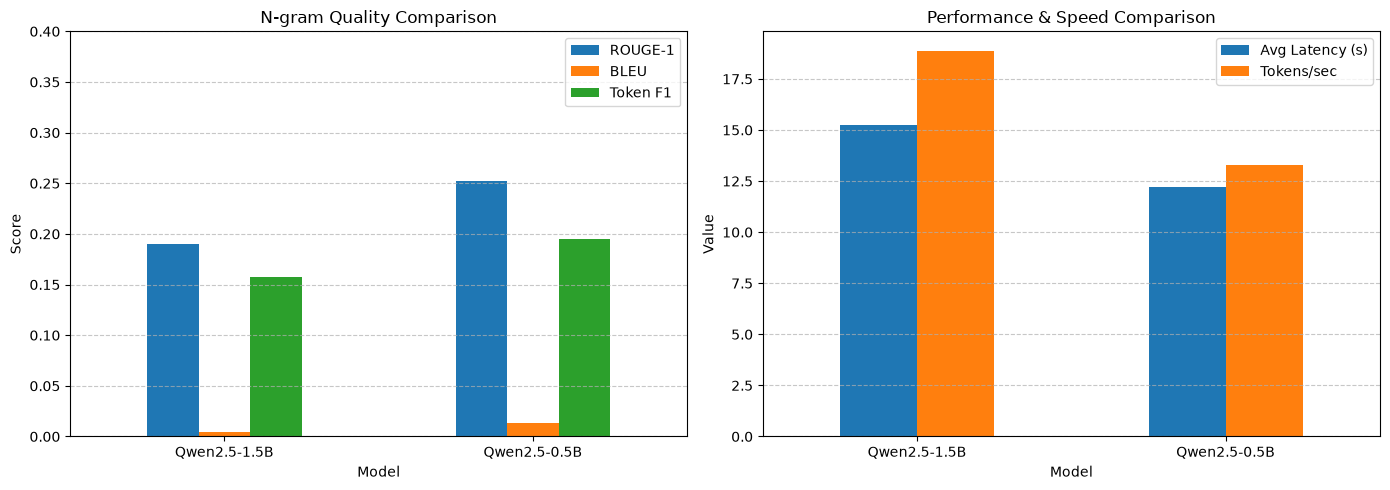

In [42]:
summary = pd.DataFrame([
    {
        "Model": "Qwen2.5-1.5B",
        "ROUGE-1": df_1_5["rouge1"].mean(),
        "BLEU": df_1_5["bleu"].mean(),
        "Token F1": df_1_5["token_f1"].mean(),
        "Avg Latency (s)": df_1_5["latency"].mean(),
        "Tokens/sec": df_1_5["tps"].mean()
    },
    {
        "Model": "Qwen2.5-0.5B",
        "ROUGE-1": df_0_5["rouge1"].mean(),
        "BLEU": df_0_5["bleu"].mean(),
        "Token F1": df_0_5["token_f1"].mean(),
        "Avg Latency (s)": df_0_5["latency"].mean(),
        "Tokens/sec": df_0_5["tps"].mean()
    }
])

print("=== KUBERNETES LLM EVALUATION SUMMARY ===")
display(summary.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

summary.plot(x="Model", y=["ROUGE-1", "BLEU", "Token F1"], kind="bar", ax=ax[0], rot=0)
ax[0].set_title("N-gram Quality Comparison")
ax[0].set_ylabel("Score")
ax[0].set_ylim(0, 0.4)
ax[0].grid(axis="y", linestyle="--", alpha=0.7)

summary.plot(x="Model", y=["Avg Latency (s)", "Tokens/sec"], kind="bar", ax=ax[1], rot=0)
ax[1].set_title("Performance & Speed Comparison")
ax[1].set_ylabel("Value")
ax[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()